In [86]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../dataset/processed/Customer-churn-clean.csv')
print(df.head(5))

   CreditScore  Gender  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
0          619       0   42       2       0.00              1          1   
1          608       0   41       1   83807.86              1          0   
2          502       0   42       8  159660.80              3          1   
3          699       0   39       1       0.00              2          0   
4          850       0   43       2  125510.82              1          1   

   IsActiveMember  EstimatedSalary  Exited  Complain  Satisfaction Score  \
0               1        101348.88       1         1                   2   
1               1        112542.58       0         1                   3   
2               0        113931.57       1         1                   3   
3               0         93826.63       0         0                   5   
4               1         79084.10       0         0                   5   

   Point Earned  Geography_France  Geography_Germany  Geography_Spain  
0           46

In [87]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CreditScore         10000 non-null  int64  
 1   Gender              10000 non-null  int64  
 2   Age                 10000 non-null  int64  
 3   Tenure              10000 non-null  int64  
 4   Balance             10000 non-null  float64
 5   NumOfProducts       10000 non-null  int64  
 6   HasCrCard           10000 non-null  int64  
 7   IsActiveMember      10000 non-null  int64  
 8   EstimatedSalary     10000 non-null  float64
 9   Exited              10000 non-null  int64  
 10  Complain            10000 non-null  int64  
 11  Satisfaction Score  10000 non-null  int64  
 12  Point Earned        10000 non-null  int64  
 13  Geography_France    10000 non-null  bool   
 14  Geography_Germany   10000 non-null  bool   
 15  Geography_Spain     10000 non-null  bool   
dtypes: bo

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,650.528800,0.545700,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203800,0.204400,3.013800,606.515100
std,96.653299,0.497932,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402842,0.403283,1.405919,225.924839
min,350.000000,0.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,1.000000,119.000000
25%,584.000000,0.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,2.000000,410.000000
50%,652.000000,1.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,0.000000,3.000000,605.000000
75%,718.000000,1.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,0.000000,4.000000,801.000000
max,850.000000,1.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000,5.000000,1000.000000


In [88]:
# Creating age groups
def categorize_age(age):
    if age < 30:
        return 0  # Young
    elif age < 45:
        return 1  # Middle
    elif age < 60:
        return 2  # Senior
    else:
        return 3  # Elderly
    
df['AgeGroup'] = df['Age'].apply(categorize_age)

print("Age Group Distribution:")
print(df['AgeGroup'].value_counts().sort_index())

Age Group Distribution:
AgeGroup
0    1641
1    6019
2    1814
3     526
Name: count, dtype: int64


In [89]:
print(df['Exited'].value_counts())

Exited
0    7962
1    2038
Name: count, dtype: int64


In [90]:
print("\nChurn rate by Age Group:")
print(df.groupby('AgeGroup')['Exited'].mean() * 100)



Churn rate by Age Group:
AgeGroup
0     7.556368
1    14.454228
2    49.448732
3    27.946768
Name: Exited, dtype: float64


In [91]:
print(df['Balance'])

0            0.00
1        83807.86
2       159660.80
3            0.00
4       125510.82
          ...    
9995         0.00
9996     57369.61
9997         0.00
9998     75075.31
9999    130142.79
Name: Balance, Length: 10000, dtype: float64


In [92]:
df['HasBalance'] = (df['Balance'] > 0).astype(int)
print(df['HasBalance'].value_counts())

HasBalance
1    6383
0    3617
Name: count, dtype: int64


In [93]:
# Churn rate by balance status
print("\nChurn rate by Balance Status:")
print(df.groupby('HasBalance')['Exited'].mean() * 100)


Churn rate by Balance Status:
HasBalance
0    13.823611
1    24.095253
Name: Exited, dtype: float64


In [94]:
# Balance per product
df['BalancePerProduct'] = df['Balance'] / df['NumOfProducts']

print("Balance per Product stats:")
print(df['BalancePerProduct'].describe())

Balance per Product stats:
count     10000.000000
mean      62819.698530
std       56783.337793
min           0.000000
25%           0.000000
50%       61166.240000
75%      112654.835000
max      238387.560000
Name: BalancePerProduct, dtype: float64


In [95]:
# Grouping customers by how long they've been with the bank
def categorize_tenure(tenure):
    if tenure <= 2:
        return 0 # New customer
    elif tenure <= 5:
        return 1 # Established customer
    else:        
        return 2 # Loyal customer
    
df['TenureGroup'] = df['Tenure'].apply(categorize_tenure)
print("\nTenure Group distribution:")
print(df['TenureGroup'].value_counts().sort_index())

print("\nChurn rate by Tenure Group:")
print(df.groupby('TenureGroup')['Exited'].mean() * 100)


Tenure Group distribution:
TenureGroup
0    2496
1    3010
2    4494
Name: count, dtype: int64

Churn rate by Tenure Group:
TenureGroup
0    21.153846
1    20.764120
2    19.692924
Name: Exited, dtype: float64


In [96]:
# credit score groups
def categorize_credit_score(score):
    if score < 500:
        return 0  # Poor score
    elif score < 650:
        return 1  # Fair score
    elif score < 750:
        return 2  # Good score
    else:
        return 3  # Excellent
    
df['CreditScoreGroup'] = df['CreditScore'].apply(categorize_credit_score)
print("\nCredit Score Group distribution:")
print(df['CreditScoreGroup'].value_counts().sort_index())

print("\nChurn rate by Credit Score Group:")
print(df.groupby('CreditScoreGroup')['Exited'].mean() * 100)


Credit Score Group distribution:
CreditScoreGroup
0     632
1    4268
2    3477
3    1623
Name: count, dtype: int64

Churn rate by Credit Score Group:
CreditScoreGroup
0    23.734177
1    21.063730
2    19.183204
3    19.839803
Name: Exited, dtype: float64


In [97]:
# Combining salary and balance to find the high value customers
median_salary = df['EstimatedSalary'].median()
median_balance = df['Balance'].median()

print("\nMedian Salary:", median_salary)
print("Median Balance:", median_balance)


Median Salary: 100193.915
Median Balance: 97198.54000000001


In [98]:
df['IsHighValue'] = ((df['EstimatedSalary'] > median_salary) & (df['Balance'] > median_balance)).astype(int)

print("\n Churn rate by High Value:")
print(df.groupby('IsHighValue')['Exited'].mean() * 100)


 Churn rate by High Value:
IsHighValue
0    18.800107
1    25.079491
Name: Exited, dtype: float64


In [99]:
# product and activity interaction
df['ActiveMultiProduct'] = ((df['IsActiveMember'] == 1) & (df['NumOfProducts'] >= 1)).astype(int)

print("Active members with products distribution:")
print(df['ActiveMultiProduct'].value_counts())

print("\n Churn rate by Active Member with Products:")
print(df.groupby('ActiveMultiProduct')['Exited'].mean() * 100)

Active members with products distribution:
ActiveMultiProduct
1    5151
0    4849
Name: count, dtype: int64

 Churn rate by Active Member with Products:
ActiveMultiProduct
0    26.871520
1    14.269074
Name: Exited, dtype: float64


In [100]:
# Evaluating the new features
new_features = ['AgeGroup', 'HasBalance', 'BalancePerProduct', 'TenureGroup', 'CreditScoreGroup', 'IsHighValue', 'ActiveMultiProduct']

print("\nChurn rate by new features:")
for feature in new_features:
    print(f"\nChurn rate by {feature}:")
    churn_rate = df.groupby(feature)['Exited'].mean() * 100
    print(churn_rate)
    diff = churn_rate.max() - churn_rate.min()
    print(f"Difference: {diff:.1f}%")


Churn rate by new features:

Churn rate by AgeGroup:
AgeGroup
0     7.556368
1    14.454228
2    49.448732
3    27.946768
Name: Exited, dtype: float64
Difference: 41.9%

Churn rate by HasBalance:
HasBalance
0    13.823611
1    24.095253
Name: Exited, dtype: float64
Difference: 10.3%

Churn rate by BalancePerProduct:
BalancePerProduct
0.0000          13.823611
1884.3450      100.000000
7131.4000        0.000000
11717.6075     100.000000
12459.1900     100.000000
                  ...    
213146.2000    100.000000
216109.8800    100.000000
221532.8000      0.000000
222267.6300    100.000000
238387.5600    100.000000
Name: Exited, Length: 6383, dtype: float64
Difference: 100.0%

Churn rate by TenureGroup:
TenureGroup
0    21.153846
1    20.764120
2    19.692924
Name: Exited, dtype: float64
Difference: 1.5%

Churn rate by CreditScoreGroup:
CreditScoreGroup
0    23.734177
1    21.063730
2    19.183204
3    19.839803
Name: Exited, dtype: float64
Difference: 4.6%

Churn rate by IsHighValue:


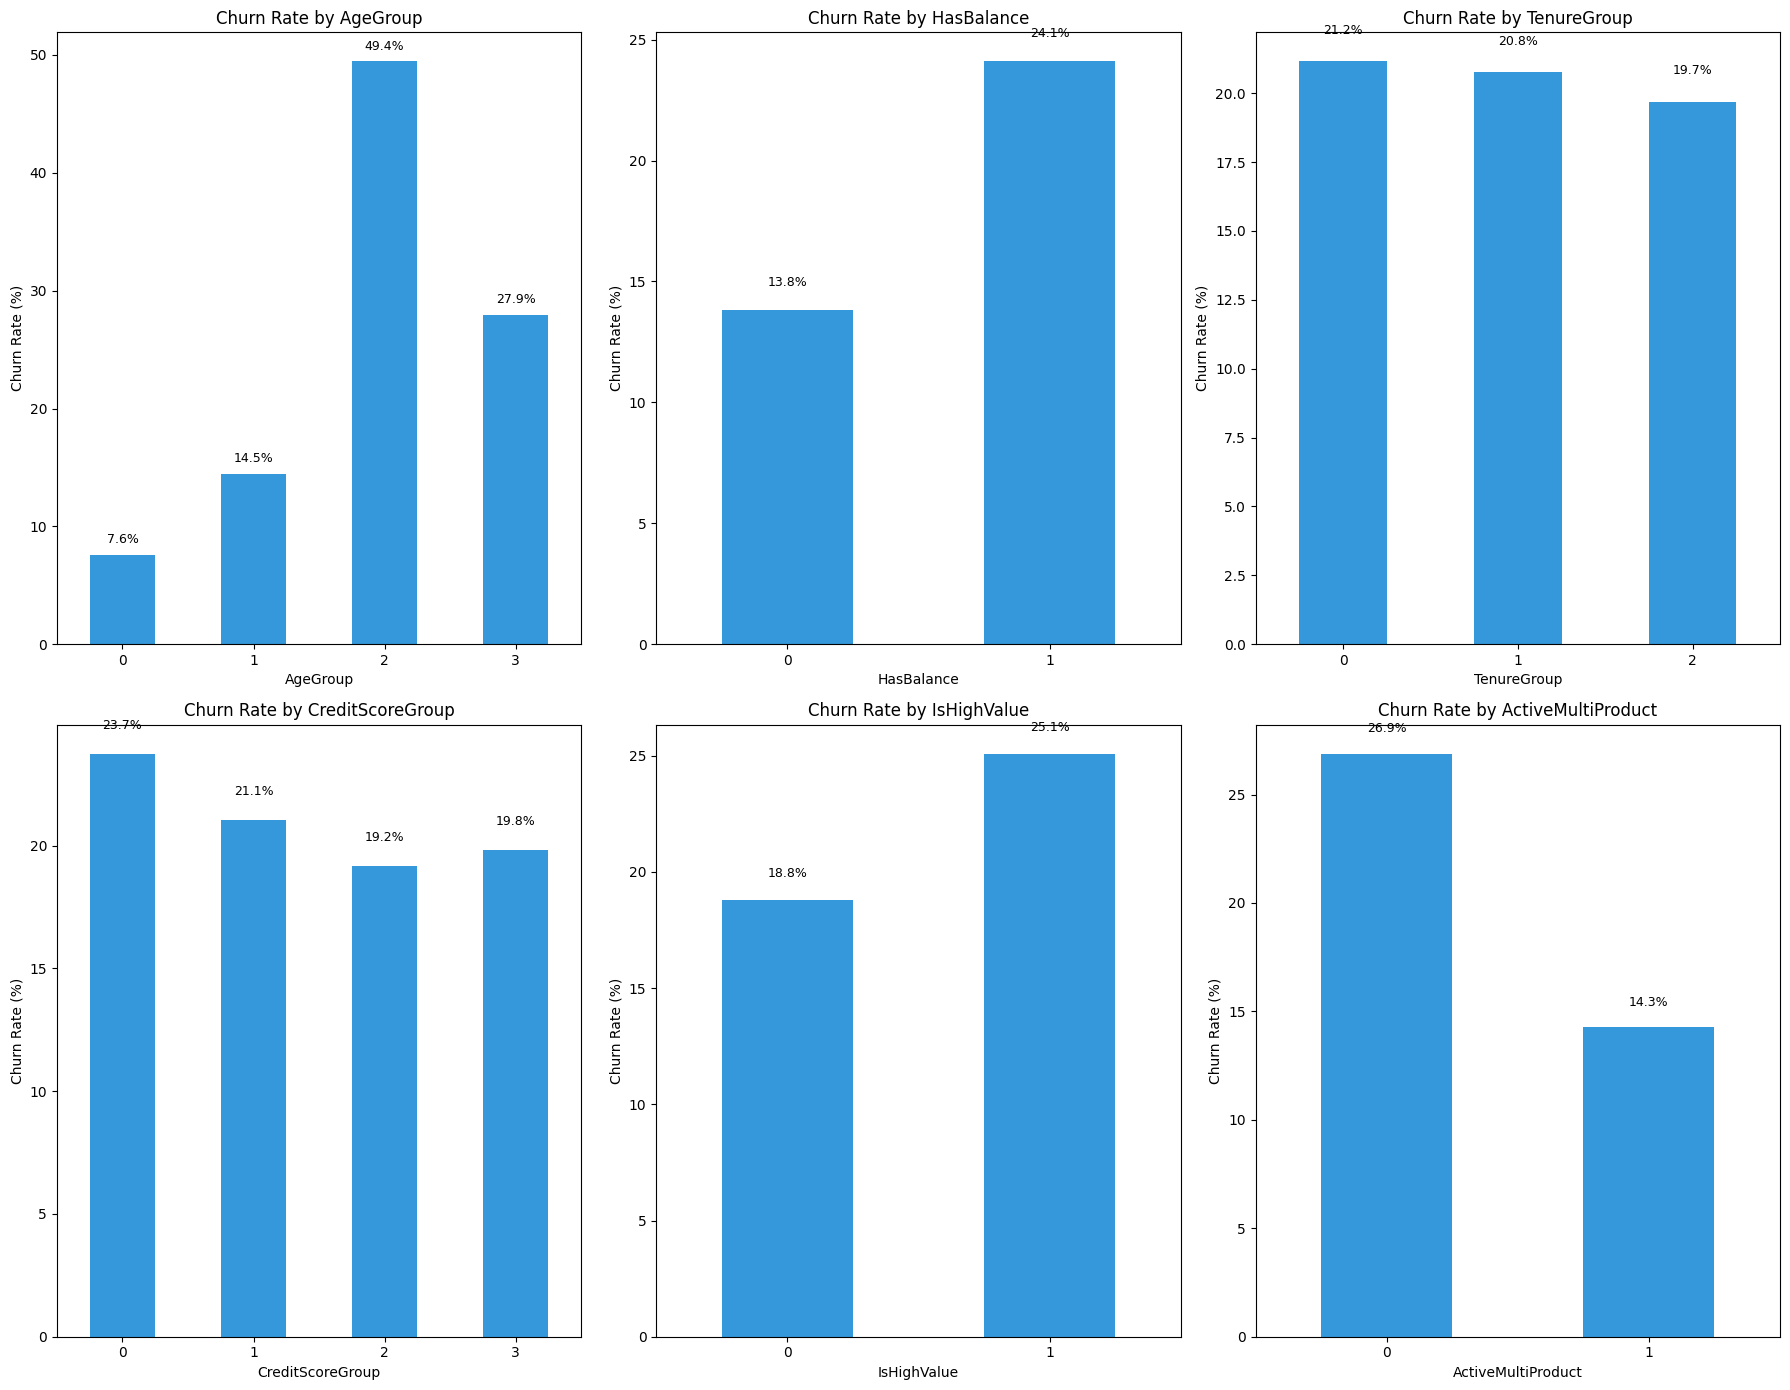

In [101]:
# Visualising new features 
fig, axes = plt.subplots(2, 3, figsize=(18, 14))

features_to_plot = ['AgeGroup', 'HasBalance', 'TenureGroup', 
                    'CreditScoreGroup', 'IsHighValue', 'ActiveMultiProduct']

for idx, feature in enumerate(features_to_plot):
    row = idx // 3
    col = idx % 3
    
    churn_rate = df.groupby(feature)['Exited'].mean() * 100
    churn_rate.plot(kind='bar', ax=axes[row, col], color='#3498db')
    axes[row, col].set_title(f'Churn Rate by {feature}')
    axes[row, col].set_ylabel('Churn Rate (%)')
    axes[row, col].set_xticklabels(axes[row, col].get_xticklabels(), rotation=0)
    
    for i, v in enumerate(churn_rate):
        axes[row, col].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/figures/engineered_features.png', dpi=300)
plt.show()

In [102]:
features_to_keep = []
features_to_drop = []

# Finding the features to keep and drop
print("\nFeature importance based on churn rate difference:")
for feature in new_features:
    churn_rate = df.groupby(feature)['Exited'].mean() * 100
    diff = churn_rate.max() - churn_rate.min()

    if diff > 5:
        features_to_keep.append(feature)
        print(f"Keep {feature} (Difference: {diff:.1f}%)")
    else:
        features_to_drop.append(feature)
        print(f"Drop {feature} (Difference: {diff:.1f}%)")



Feature importance based on churn rate difference:
Keep AgeGroup (Difference: 41.9%)
Keep HasBalance (Difference: 10.3%)
Keep BalancePerProduct (Difference: 100.0%)
Drop TenureGroup (Difference: 1.5%)
Drop CreditScoreGroup (Difference: 4.6%)
Keep IsHighValue (Difference: 6.3%)
Keep ActiveMultiProduct (Difference: 12.6%)


In [103]:
print("\nFeatures to keep:", features_to_keep)
print("Features to drop:", features_to_drop)


Features to keep: ['AgeGroup', 'HasBalance', 'BalancePerProduct', 'IsHighValue', 'ActiveMultiProduct']
Features to drop: ['TenureGroup', 'CreditScoreGroup']


In [104]:
print(df.describe())

        CreditScore        Gender           Age        Tenure        Balance  \
count  10000.000000  10000.000000  10000.000000  10000.000000   10000.000000   
mean     650.528800      0.545700     38.921800      5.012800   76485.889288   
std       96.653299      0.497932     10.487806      2.892174   62397.405202   
min      350.000000      0.000000     18.000000      0.000000       0.000000   
25%      584.000000      0.000000     32.000000      3.000000       0.000000   
50%      652.000000      1.000000     37.000000      5.000000   97198.540000   
75%      718.000000      1.000000     44.000000      7.000000  127644.240000   
max      850.000000      1.000000     92.000000     10.000000  250898.090000   

       NumOfProducts    HasCrCard  IsActiveMember  EstimatedSalary  \
count   10000.000000  10000.00000    10000.000000     10000.000000   
mean        1.530200      0.70550        0.515100    100090.239881   
std         0.581654      0.45584        0.499797     57510.492818   

In [105]:
# Dropping the less important features
if features_to_drop:
    df = df.drop(columns=features_to_drop)
    print(f"\nDropped: {features_to_drop}")
print(f"\nFinal shape: {df.shape}")
print(f"\nFinal columns: {df.columns.tolist()}")


Dropped: ['TenureGroup', 'CreditScoreGroup']

Final shape: (10000, 21)

Final columns: ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Complain', 'Satisfaction Score', 'Point Earned', 'Geography_France', 'Geography_Germany', 'Geography_Spain', 'AgeGroup', 'HasBalance', 'BalancePerProduct', 'IsHighValue', 'ActiveMultiProduct']


In [106]:
# Checking correlation of new features with target
correlations = df.corr()['Exited'].sort_values(ascending=False)
print("Correlation with Churn:")
print(correlations)

Correlation with Churn:
Exited                1.000000
Complain              0.995693
Age                   0.285296
AgeGroup              0.275890
Geography_Germany     0.173313
HasBalance            0.122522
Balance               0.118577
BalancePerProduct     0.109714
IsHighValue           0.067644
EstimatedSalary       0.012490
Point Earned         -0.004628
Satisfaction Score   -0.005849
HasCrCard            -0.006976
Tenure               -0.013656
CreditScore          -0.026771
NumOfProducts        -0.047611
Geography_Spain      -0.052800
Geography_France     -0.104688
Gender               -0.106267
ActiveMultiProduct   -0.156356
IsActiveMember       -0.156356
Name: Exited, dtype: float64


In [107]:
# Saving the final dataset
df.to_csv('../dataset/processed/bank_churn_featured.csv', index=False)

print("Feature-engineered dataset saved!")
print(f"Final shape: {df.shape}")

Feature-engineered dataset saved!
Final shape: (10000, 21)


============================================================
FEATURE ENGINEERING SUMMARY
============================================================

NEW FEATURES CREATED:
---------------------
1. AgeGroup         - Categorized age into Young/Middle/Senior/Elderly
2. HasBalance       - Flag for customers with non-zero balance
3. BalancePerProduct- Balance divided by number of products
4. TenureGroup      - New/Established/Loyal customer categories
5. CreditCategory   - Credit score bands
6. IsHighValue      - High salary AND high balance customers
7. ActiveMultiProduct - Active members with 2+ products

FEATURES KEPT:
--------------
Based on churn rate difference > 5% i have kept the features 'AgeGroup', 'HasBalance', 'BalancePerProduct', 'IsHighValue' and  'ActiveMultiProduct'.


FEATURES DROPPED:
-----------------
Based on churn rate difference < 3% i have dropped the features 'TenureGroup' and 'CreditScoreGroup'
============================================================